## This is the first notebook of the data ingestion

In [8]:
!pip -q install \
lightkurve \
astroquery \
astropy \
pandas \
numpy \
matplotlib \
plotly \
tqdm \
pyarrow \
requests \
beautifulsoup4 \
lxml

In [9]:
import os
import gc
import json
import time
import shutil
import logging
import warnings
import requests
import random

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import plotly.express as px

from astroquery.mast import Catalogs

import lightkurve as lk

warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [10]:
PROJECT_NAME = "Exoplanet_Detection"

ROOT_DIR = Path("D:/Machine Learning/") / PROJECT_NAME

DATA_DIR = ROOT_DIR / "data"

RAW_DIR = DATA_DIR / "raw"

PROCESSED_DIR = DATA_DIR / "processed"

CATALOG_DIR = RAW_DIR / "catalogs"

LIGHTCURVE_DIR = RAW_DIR / "lightcurves"

LOG_DIR = ROOT_DIR / "logs"

REPORT_DIR = ROOT_DIR / "reports"

MODEL_DIR = ROOT_DIR / "models"

FIGURE_DIR = REPORT_DIR / "figures"

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

print(ROOT_DIR)

D:\Machine Learning\Exoplanet_Detection


In [11]:
directories = [
    DATA_DIR,
    RAW_DIR,
    PROCESSED_DIR,
    CATALOG_DIR,
    LIGHTCURVE_DIR,
    LOG_DIR,
    REPORT_DIR,
    MODEL_DIR,
    FIGURE_DIR
]

for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)

print("Directory Structure Created Successfully")

Directory Structure Created Successfully


In [12]:
LOG_FILE = LOG_DIR / "notebook_01.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler(LOG_FILE),
        logging.StreamHandler()
    ],
    force=True
)

logger = logging.getLogger("Notebook01")

logger.info("Notebook 01 Started")

2026-07-22 04:06:39,468 | INFO | Notebook 01 Started


In [13]:
def print_header(title: str) -> None:
    """
    Display a formatted section header.
    """
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def save_dataframe(df: pd.DataFrame,
                   name: str,
                   directory: Path = PROCESSED_DIR) -> None:
    """
    Save a DataFrame as CSV and Parquet.
    """
    csv_path = directory / f"{name}.csv"
    parquet_path = directory / f"{name}.parquet"

    df.to_csv(csv_path, index=False)
    df.to_parquet(parquet_path, index=False)

    logger.info(f"Saved {csv_path.name}")
    logger.info(f"Saved {parquet_path.name}")


def dataset_summary(df: pd.DataFrame) -> None:
    """
    Print dataset summary.
    """
    print_header("Dataset Summary")

    print(f"Rows    : {len(df):,}")
    print(f"Columns : {len(df.columns)}")

    memory = df.memory_usage(deep=True).sum() / 1024**2

    print(f"Memory  : {memory:.2f} MB")


def missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Missing values summary.
    """
    return (
        df.isnull()
          .sum()
          .sort_values(ascending=False)
          .to_frame("Missing")
    )


def remove_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove duplicate rows.
    """
    before = len(df)

    df = df.drop_duplicates()

    after = len(df)

    logger.info(f"Removed {before-after} duplicate rows")

    return df


print("Utility Functions Loaded")

Utility Functions Loaded


In [14]:
print_header("Environment")

print(f"Pandas      : {pd.__version__}")
print(f"Numpy       : {np.__version__}")
print(f"Lightkurve  : {lk.__version__}")

logger.info("Environment Verified")

2026-07-22 04:06:39,500 | INFO | Environment Verified



Environment
Pandas      : 2.3.3
Numpy       : 2.4.6
Lightkurve  : 2.6.0


In [15]:
print_header("Project Configuration")

print(f"Project Name : {PROJECT_NAME}")

print(f"Root Folder  : {ROOT_DIR}")

print(f"Catalog Dir  : {CATALOG_DIR}")

print(f"Processed    : {PROCESSED_DIR}")

print(f"Seed         : {SEED}")

logger.info("Configuration Loaded Successfully")

2026-07-22 04:06:39,518 | INFO | Configuration Loaded Successfully



Project Configuration
Project Name : Exoplanet_Detection
Root Folder  : D:\Machine Learning\Exoplanet_Detection
Catalog Dir  : D:\Machine Learning\Exoplanet_Detection\data\raw\catalogs
Processed    : D:\Machine Learning\Exoplanet_Detection\data\processed
Seed         : 42


In [16]:
from urllib.parse import quote_plus

import requests

print("API utilities loaded.")

API utilities loaded.


In [17]:
BASE_URL = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"

PLANET_QUERY = """
SELECT
    pl_name,
    tic_id,
    hostname,
    ra,
    dec,
    disc_year,
    pl_orbper,
    pl_rade,
    pl_bmasse,
    st_teff,
    st_rad,
    st_mass,
    sy_dist
FROM pscomppars
WHERE tic_id IS NOT NULL
"""

print("TAP query configured.")

TAP query configured.


In [18]:
params = {
    "query": PLANET_QUERY,
    "format": "csv"
}

response = requests.get(BASE_URL, params=params, timeout=300)
response.raise_for_status()

planet_catalog_path = CATALOG_DIR / "confirmed_planets.csv"

with open(planet_catalog_path, "wb") as f:
    f.write(response.content)

logger.info("Confirmed planet catalog downloaded.")

print(f"Saved to: {planet_catalog_path}")

2026-07-22 04:07:14,423 | INFO | Confirmed planet catalog downloaded.


Saved to: D:\Machine Learning\Exoplanet_Detection\data\raw\catalogs\confirmed_planets.csv


In [19]:
planet_df = pd.read_csv(
    planet_catalog_path,
    low_memory=False
)

dataset_summary(planet_df)

planet_df.head()


Dataset Summary
Rows    : 6,028
Columns : 13
Memory  : 1.49 MB


,pl_name,tic_id,hostname,ra,dec,disc_year,pl_orbper,pl_rade,pl_bmasse,st_teff,st_rad,st_mass,sy_dist
0,Kepler-1597 b,TIC 158722002,Kepler-1597,288.163969,42.481012,2016,2.946542,1.06,1.20,6377.0,1.390,1.250,1221.050
1,Kepler-687 b,TIC 121988890,Kepler-687,289.315458,39.153291,2016,20.505870,3.52,12.20,4841.0,0.730,0.770,633.660
2,Kepler-1596 b,TIC 350813882,Kepler-1596,285.557507,49.330087,2016,66.373379,1.90,4.27,5706.0,0.920,0.950,2146.230
3,Kepler-692 b,TIC 138728891,Kepler-692,294.776807,40.153703,2016,21.812935,3.11,9.85,5440.0,0.860,0.900,991.336
4,Kepler-150 c,TIC 121598758,Kepler-150,288.234103,40.520897,2014,7.381998,3.69,13.20,5560.0,0.939,0.956,891.092


In [20]:
print_header("Validation")

print(f"Rows           : {len(planet_df):,}")
print(f"Columns        : {len(planet_df.columns)}")
print(f"Duplicate Rows : {planet_df.duplicated().sum()}")

print("\nMissing Values:")
display(missing_values(planet_df).head(15))


Validation
Rows           : 6,028
Columns        : 13
Duplicate Rows : 0

Missing Values:


,Missing
pl_orbper,72
pl_rade,48
pl_bmasse,31
st_rad,29
sy_dist,21
st_teff,11
st_mass,9
dec,0
tic_id,0
pl_name,0


In [21]:
planet_df = remove_duplicates(planet_df)

planet_df.reset_index(drop=True, inplace=True)

dataset_summary(planet_df)

2026-07-22 04:07:14,660 | INFO | Removed 0 duplicate rows



Dataset Summary
Rows    : 6,028
Columns : 13
Memory  : 1.49 MB


In [22]:
save_dataframe(
    planet_df,
    "confirmed_planets_clean",
    CATALOG_DIR
)

logger.info("Clean catalog saved.")

2026-07-22 04:07:20,182 | INFO | Saved confirmed_planets_clean.csv
2026-07-22 04:07:20,183 | INFO | Saved confirmed_planets_clean.parquet
2026-07-22 04:07:20,185 | INFO | Clean catalog saved.


In [23]:
COLUMN_MAPPING = {
    "pl_name": "planet_name",
    "hostname": "host_star",
    "tic_id": "tic_id",
    "ra": "ra",
    "dec": "dec",
    "disc_year": "discovery_year",
    "pl_orbper": "orbital_period_days",
    "pl_rade": "planet_radius_earth",
    "pl_bmasse": "planet_mass_earth",
    "st_teff": "stellar_teff",
    "st_rad": "stellar_radius",
    "st_mass": "stellar_mass",
    "sy_dist": "distance_pc"
}

planet_df.rename(columns=COLUMN_MAPPING, inplace=True)

logger.info("Column names standardized.")

2026-07-22 04:07:20,201 | INFO | Column names standardized.


In [24]:
MASTER_COLUMNS = [

    "tic_id",

    "planet_name",

    "host_star",

    "ra",

    "dec",

    "orbital_period_days",

    "planet_radius_earth",

    "planet_mass_earth",

    "stellar_teff",

    "stellar_radius",

    "stellar_mass",

    "distance_pc",

    "discovery_year"

]

master_catalog = planet_df[MASTER_COLUMNS].copy()

master_catalog.head()

,tic_id,planet_name,host_star,ra,dec,orbital_period_days,planet_radius_earth,planet_mass_earth,stellar_teff,stellar_radius,stellar_mass,distance_pc,discovery_year
0,TIC 158722002,Kepler-1597 b,Kepler-1597,288.163969,42.481012,2.946542,1.06,1.20,6377.0,1.390,1.250,1221.050,2016
1,TIC 121988890,Kepler-687 b,Kepler-687,289.315458,39.153291,20.505870,3.52,12.20,4841.0,0.730,0.770,633.660,2016
2,TIC 350813882,Kepler-1596 b,Kepler-1596,285.557507,49.330087,66.373379,1.90,4.27,5706.0,0.920,0.950,2146.230,2016
3,TIC 138728891,Kepler-692 b,Kepler-692,294.776807,40.153703,21.812935,3.11,9.85,5440.0,0.860,0.900,991.336,2016
4,TIC 121598758,Kepler-150 c,Kepler-150,288.234103,40.520897,7.381998,3.69,13.20,5560.0,0.939,0.956,891.092,2014


In [25]:
master_catalog["tic_id"] = (
    master_catalog["tic_id"]
    .astype(str)
    .str.replace("TIC", "", regex=False)
    .str.strip()
)

master_catalog["tic_id"] = pd.to_numeric(
    master_catalog["tic_id"],
    errors="coerce"
).astype("Int64")

float_columns = [
    "ra",
    "dec",
    "orbital_period_days",
    "planet_radius_earth",
    "planet_mass_earth",
    "stellar_teff",
    "stellar_radius",
    "stellar_mass",
    "distance_pc"
]

for col in float_columns:
    master_catalog[col] = pd.to_numeric(
        master_catalog[col],
        errors="coerce"
    )

master_catalog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6028 entries, 0 to 6027
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tic_id               6028 non-null   Int64  
 1   planet_name          6028 non-null   object 
 2   host_star            6028 non-null   object 
 3   ra                   6028 non-null   float64
 4   dec                  6028 non-null   float64
 5   orbital_period_days  5956 non-null   float64
 6   planet_radius_earth  5980 non-null   float64
 7   planet_mass_earth    5997 non-null   float64
 8   stellar_teff         6017 non-null   float64
 9   stellar_radius       5999 non-null   float64
 10  stellar_mass         6019 non-null   float64
 11  distance_pc          6007 non-null   float64
 12  discovery_year       6028 non-null   int64  
dtypes: Int64(1), float64(9), int64(1), object(2)
memory usage: 618.2+ KB


In [26]:
master_catalog["class_label"] = "Planet"

master_catalog["class_id"] = 0

master_catalog["source_catalog"] = "NASA Exoplanet Archive"

master_catalog.head()

,tic_id,planet_name,host_star,ra,dec,orbital_period_days,planet_radius_earth,planet_mass_earth,stellar_teff,stellar_radius,stellar_mass,distance_pc,discovery_year,class_label,class_id,source_catalog
0,158722002,Kepler-1597 b,Kepler-1597,288.163969,42.481012,2.946542,1.06,1.20,6377.0,1.390,1.250,1221.050,2016,Planet,0,NASA Exoplanet Archive
1,121988890,Kepler-687 b,Kepler-687,289.315458,39.153291,20.505870,3.52,12.20,4841.0,0.730,0.770,633.660,2016,Planet,0,NASA Exoplanet Archive
2,350813882,Kepler-1596 b,Kepler-1596,285.557507,49.330087,66.373379,1.90,4.27,5706.0,0.920,0.950,2146.230,2016,Planet,0,NASA Exoplanet Archive
3,138728891,Kepler-692 b,Kepler-692,294.776807,40.153703,21.812935,3.11,9.85,5440.0,0.860,0.900,991.336,2016,Planet,0,NASA Exoplanet Archive
4,121598758,Kepler-150 c,Kepler-150,288.234103,40.520897,7.381998,3.69,13.20,5560.0,0.939,0.956,891.092,2014,Planet,0,NASA Exoplanet Archive


In [27]:
missing = (
    master_catalog
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

display(missing)

orbital_period_days    72
planet_radius_earth    48
planet_mass_earth      31
stellar_radius         29
distance_pc            21
stellar_teff           11
stellar_mass            9
tic_id                  0
dec                     0
planet_name             0
host_star               0
ra                      0
discovery_year          0
class_label             0
class_id                0
source_catalog          0
dtype: int64

In [28]:
stats = {

    "rows": int(len(master_catalog)),

    "columns": int(len(master_catalog.columns)),

    "unique_host_stars": int(master_catalog["host_star"].nunique()),

    "unique_tic_ids": int(master_catalog["tic_id"].nunique()),

    "missing_tic_ids": int(master_catalog["tic_id"].isnull().sum()),

    "generation_time": str(datetime.now()),

    "source": "NASA Exoplanet Archive"

}


In [29]:
stats

{'rows': 6028,
 'columns': 16,
 'unique_host_stars': 4453,
 'unique_tic_ids': 4453,
 'missing_tic_ids': 0,
 'generation_time': '2026-07-22 04:07:20.388995',
 'source': 'NASA Exoplanet Archive'}

In [30]:
statistics_file = REPORT_DIR / "dataset_statistics.json"

with open(statistics_file, "w") as f:

    json.dump(stats, f, indent=4)

logger.info("Statistics saved.")

2026-07-22 04:07:20,415 | INFO | Statistics saved.


In [31]:
save_dataframe(

    master_catalog,

    "master_catalog",

    PROCESSED_DIR

)

logger.info("Master catalog saved.")

2026-07-22 04:07:20,514 | INFO | Saved master_catalog.csv
2026-07-22 04:07:20,515 | INFO | Saved master_catalog.parquet
2026-07-22 04:07:20,516 | INFO | Master catalog saved.


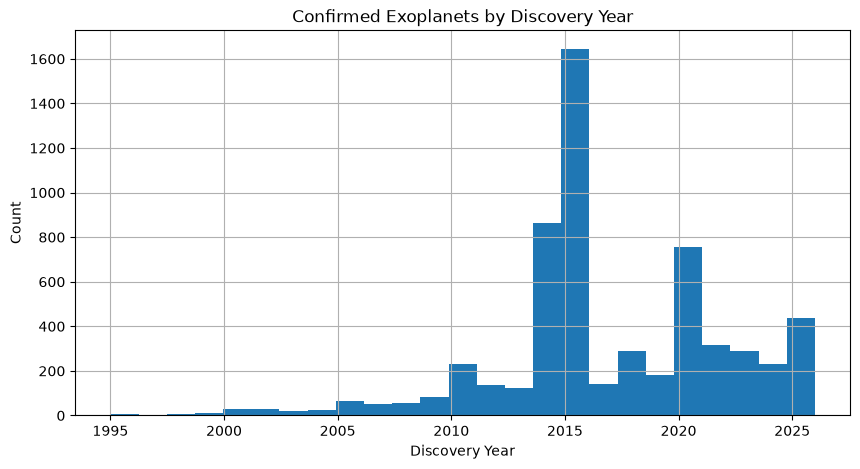

In [32]:
plt.figure(figsize=(10,5))

master_catalog["discovery_year"].hist(
    bins=25
)

plt.title("Confirmed Exoplanets by Discovery Year")

plt.xlabel("Discovery Year")

plt.ylabel("Count")

plt.show()

In [33]:

print_header("Notebook 01 Summary")

print(f"Master Catalog Shape : {master_catalog.shape}")

print(f"Unique Host Stars    : {master_catalog['host_star'].nunique()}")

print(f"Unique TIC IDs       : {master_catalog['tic_id'].nunique()}")

print(f"Output Directory     : {PROCESSED_DIR}")

print(f"Log File             : {LOG_FILE}")

logger.info("Notebook 01 Completed Successfully.")

2026-07-22 04:07:20,826 | INFO | Notebook 01 Completed Successfully.



Notebook 01 Summary
Master Catalog Shape : (6028, 16)
Unique Host Stars    : 4453
Unique TIC IDs       : 4453
Output Directory     : D:\Machine Learning\Exoplanet_Detection\data\processed
Log File             : D:\Machine Learning\Exoplanet_Detection\logs\notebook_01.log
